# Volume / Loss Simulator

This notebook simulates repeated buy/sell cycles and stops when cumulative loss reaches a configured limit. It does **not** place live orders.

Default assumptions:
- Loss limit: `$5`
- Starting cash: `$165`
- Average spread: `50 bps`
- Taker fee: `4 bps per side`
- One round trip is one buy at ask and one sell at bid.
- Total volume counts both buy and sell legs.

In [1]:
from __future__ import annotations

import pandas as pd
import matplotlib.pyplot as plt

# Parameters
LOSS_LIMIT_USD = 5.00
START_CASH_USD = 165.00
MID_PRICE = 60_000.00
SPREAD_BPS = 50.0
TAKER_FEE_BPS = 4.0

# How much quote currency to deploy per buy leg. Keep this below START_CASH_USD.
BUY_NOTIONAL_USD = 100.00

half_spread = MID_PRICE * (SPREAD_BPS / 10_000) / 2
bid = MID_PRICE - half_spread
ask = MID_PRICE + half_spread

print(f'bid={bid:,.2f} ask={ask:,.2f} spread={ask-bid:,.2f}')

bid=59,850.00 ask=60,150.00 spread=300.00


In [2]:
def simulate_until_loss(
    *,
    start_cash: float,
    loss_limit: float,
    buy_notional: float,
    bid_price: float,
    ask_price: float,
    taker_fee_bps: float,
) -> pd.DataFrame:
    cash = start_cash
    btc = 0.0
    trade_count = 0
    total_volume = 0.0
    rows = []

    fee_rate = taker_fee_bps / 10_000

    def mark_value() -> float:
        return cash + btc * ((bid_price + ask_price) / 2)

    while start_cash - mark_value() < loss_limit:
        # Buy at ask.
        gross_buy = min(buy_notional, cash / (1 + fee_rate))
        if gross_buy <= 0:
            break
        qty = gross_buy / ask_price
        fee = gross_buy * fee_rate
        cash -= gross_buy + fee
        btc += qty
        trade_count += 1
        total_volume += gross_buy
        rows.append({
            'trade': trade_count,
            'side': 'buy',
            'price': ask_price,
            'qty_btc': qty,
            'notional_usd': gross_buy,
            'fee_usd': fee,
            'cash_usd': cash,
            'btc': btc,
            'portfolio_value_usd': mark_value(),
            'cum_loss_usd': start_cash - mark_value(),
            'total_volume_usd': total_volume,
        })

        if start_cash - mark_value() >= loss_limit:
            break

        # Sell all acquired BTC at bid.
        gross_sell = btc * bid_price
        fee = gross_sell * fee_rate
        cash += gross_sell - fee
        btc = 0.0
        trade_count += 1
        total_volume += gross_sell
        rows.append({
            'trade': trade_count,
            'side': 'sell',
            'price': bid_price,
            'qty_btc': qty,
            'notional_usd': gross_sell,
            'fee_usd': fee,
            'cash_usd': cash,
            'btc': btc,
            'portfolio_value_usd': mark_value(),
            'cum_loss_usd': start_cash - mark_value(),
            'total_volume_usd': total_volume,
        })

    return pd.DataFrame(rows)


df = simulate_until_loss(
    start_cash=START_CASH_USD,
    loss_limit=LOSS_LIMIT_USD,
    buy_notional=BUY_NOTIONAL_USD,
    bid_price=bid,
    ask_price=ask,
    taker_fee_bps=TAKER_FEE_BPS,
)

df.tail(10)

,trade,side,price,qty_btc,notional_usd,fee_usd,cash_usd,btc,portfolio_value_usd,cum_loss_usd,total_volume_usd
8,9,buy,60150.0,0.001663,100.000000,0.0400,62.645786,0.001663,162.396409,2.603591,898.004988
9,10,sell,59850.0,0.001663,99.501247,0.0398,162.107232,0.000000,162.107232,2.892768,997.506234
10,11,buy,60150.0,0.001663,100.000000,0.0400,62.067232,0.001663,161.817855,3.182145,1097.506234
11,12,sell,59850.0,0.001663,99.501247,0.0398,161.528678,0.000000,161.528678,3.471322,1197.007481
12,13,buy,60150.0,0.001663,100.000000,0.0400,61.488678,0.001663,161.239302,3.760698,1297.007481
13,14,sell,59850.0,0.001663,99.501247,0.0398,160.950125,0.000000,160.950125,4.049875,1396.508728
14,15,buy,60150.0,0.001663,100.000000,0.0400,60.910125,0.001663,160.660748,4.339252,1496.508728
15,16,sell,59850.0,0.001663,99.501247,0.0398,160.371571,0.000000,160.371571,4.628429,1596.009975
16,17,buy,60150.0,0.001663,100.000000,0.0400,60.331571,0.001663,160.082195,4.917805,1696.009975
17,18,sell,59850.0,0.001663,99.501247,0.0398,159.793017,0.000000,159.793017,5.206983,1795.511222


In [3]:
summary = {
    'trades': int(df['trade'].iloc[-1]) if len(df) else 0,
    'round_trips': int((df['side'] == 'sell').sum()) if len(df) else 0,
    'final_portfolio_value_usd': float(df['portfolio_value_usd'].iloc[-1]) if len(df) else START_CASH_USD,
    'cum_loss_usd': float(df['cum_loss_usd'].iloc[-1]) if len(df) else 0.0,
    'total_volume_usd': float(df['total_volume_usd'].iloc[-1]) if len(df) else 0.0,
}

pd.Series(summary).to_frame('value')

,value
trades,18.000000
round_trips,9.000000
final_portfolio_value_usd,159.793017
cum_loss_usd,5.206983
total_volume_usd,1795.511222


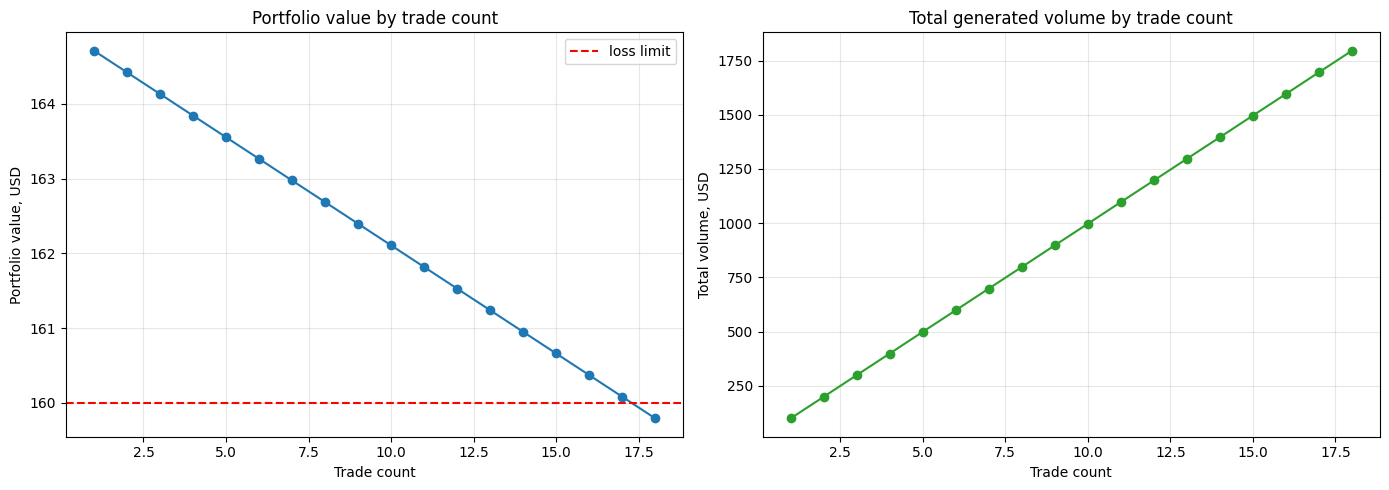

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df['trade'], df['portfolio_value_usd'], marker='o')
axes[0].axhline(START_CASH_USD - LOSS_LIMIT_USD, color='red', linestyle='--', label='loss limit')
axes[0].set_title('Portfolio value by trade count')
axes[0].set_xlabel('Trade count')
axes[0].set_ylabel('Portfolio value, USD')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df['trade'], df['total_volume_usd'], marker='o', color='tab:green')
axes[1].set_title('Total generated volume by trade count')
axes[1].set_xlabel('Trade count')
axes[1].set_ylabel('Total volume, USD')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

In [5]:
# Full simulated trade log. Change the path if you want a different output file.
output_path = '../simulated_volume_loss_log.csv'
df.to_csv(output_path, index=False)
print(f'wrote {len(df)} rows to {output_path}')

wrote 18 rows to ../simulated_volume_loss_log.csv
